# XGBoost Dark Matter Estimation on SPARC Data
1. Combines the 4 SPARC training datasets (`galaxies.csv`, `stellar-masses.csv`, `BTF.csv`, `newt-mass.csv`) into a single master file `data/sparc_combined_train.csv` while keeping all 4 separate CSVs intact.
2. Calculates physical target Dark Matter Fraction ($f_{\text{DM}}$) from rotation curve decomposition at outer radius $R_{\text{max}}$.
3. Engineers physics-motivated features (gas fraction, mass-discrepancy proxy, $R_{\max}/R_{\mathrm{disk}}$, etc.) while excluding label-leaking columns (`V_baryon_outer`, `V_obs_outer`).
4. Trains a regularized XGBoost regressor with 5-fold cross-validation and reports train–test R² gap to monitor overfitting.
5. Uses SHAP to identify which observable properties most determine dark matter fraction.


In [1]:
# Run once — comment out after first run
# !pip install xgboost scikit-learn pandas numpy shap --quiet

In [2]:
import os
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("All imports successful.")
print(f"XGBoost version: {xgb.__version__}")

/Users/aaravsharma/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful.
XGBoost version: 3.4.0


In [3]:
USE_SYNTHETIC      = False          # Set True only for synthetic test fallback
TRAIN_DIR          = "data/train"
COMBINED_CSV_PATH  = "data/train/combined/sparc_combined_train.csv"

# Lean feature set: base observables + physics-motivated ratios.
# Excludes V_baryon_outer / V_obs_outer (those define the target).
FEATURE_COLS = [
    "stellar_mass_logM",
    "baryonic_mass_logMb",
    "surface_brightness_SBeff",
    "disk_scale_length_Rdisk",
    "rotation_velocity_Vflat",
    "morph_type_T",
    "R_max_kpc",
    "Rmax_over_Rd",
    "gas_fraction",
    "log_mass_discrepancy_proxy",
    "V_over_sqrt_Mb",
    "log_MHI",
]

TARGET_COL   = "dm_fraction"
RANDOM_STATE = 42
N_FOLDS      = 5


In [4]:
from create_combined_sparc_dataset import build_combined_sparc_dataset

def make_synthetic_sparc(n=175, seed=42):
    """Synthetic SPARC-like fallback data."""
    rng = np.random.default_rng(seed)
    stellar_mass = 10 ** rng.uniform(7, 12, n) / 1e9
    gas_mass     = stellar_mass * rng.uniform(0.05, 2.0, n)
    luminosity   = stellar_mass * rng.uniform(0.5, 3.0, n)
    radius       = rng.uniform(1, 30, n)
    surf_bright  = luminosity / (np.pi * radius**2)
    vflat        = rng.uniform(50, 350, n)
    rdisk        = radius * 0.6
    r_max        = rdisk * rng.uniform(3.0, 8.0, n)
    dm_fraction  = np.clip(
        1.0 - surf_bright / surf_bright.max() * 0.8 + rng.normal(0, 0.1, n),
        0.05, 0.98
    )
    return pd.DataFrame({
        "Galaxy":                      [f"SYN_{i:03d}" for i in range(n)],
        "stellar_mass_logM":           np.log10(stellar_mass * 1e9),
        "HI_gas_mass_MHI":             gas_mass,
        "baryonic_mass_logMb":         np.log10((stellar_mass + gas_mass) * 1e9),
        "effective_radius_Reff":       radius,
        "surface_brightness_SBeff":    surf_bright,
        "disk_scale_length_Rdisk":     rdisk,
        "rotation_velocity_Vflat":     vflat,
        "color_3p6_4p5":               rng.uniform(2.5, 4.5, n),
        "morph_type_T":                rng.integers(1, 11, n),
        "R_max_kpc":                   r_max,
        "dm_fraction":                 dm_fraction,
    })


def add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Physics-motivated features that do not leak V_baryon / V_obs used in the label."""
    out = frame.copy()
    Mb = np.power(10.0, out["baryonic_mass_logMb"])
    Mhi = out["HI_gas_mass_MHI"] * 1e9
    Vf = out["rotation_velocity_Vflat"].clip(lower=1.0)
    Rd = out["disk_scale_length_Rdisk"].clip(lower=0.01)

    out["gas_fraction"] = Mhi / Mb
    out["log_mass_discrepancy_proxy"] = np.log10((2.325e5 * Vf**2 * Rd) / Mb)
    out["V_over_sqrt_Mb"] = Vf / np.sqrt(Mb)
    out["log_MHI"] = np.log10(out["HI_gas_mass_MHI"].clip(lower=1e-4))

    if "R_max_kpc" not in out.columns:
        out["R_max_kpc"] = Rd * 5.0
    out["Rmax_over_Rd"] = out["R_max_kpc"] / Rd
    return out


if USE_SYNTHETIC:
    df = make_synthetic_sparc()
    print("Using synthetic data (175 galaxies)")
else:
    # Generate combined dataset from 4 separate CSVs if not present
    if not os.path.exists(COMBINED_CSV_PATH):
        df = build_combined_sparc_dataset(train_dir=TRAIN_DIR, output_csv=COMBINED_CSV_PATH)
    else:
        df = pd.read_csv(COMBINED_CSV_PATH)
        print(f"Loaded combined dataset from '{COMBINED_CSV_PATH}' ({len(df)} galaxies)")

df = add_engineered_features(df)
print(f"Shape: {df.shape}")
df[["Galaxy", "stellar_mass_logM", "gas_fraction", "log_mass_discrepancy_proxy",
    "R_max_kpc", "Rmax_over_Rd", "rotation_velocity_Vflat", "dm_fraction"]].head()


Loaded combined dataset from 'data/train/combined/sparc_combined_train.csv' (140 galaxies)
Shape: (140, 23)


,Galaxy,stellar_mass_logM,gas_fraction,log_mass_discrepancy_proxy,R_max_kpc,Rmax_over_Rd,rotation_velocity_Vflat,dm_fraction
0,UGC08286,8.990000,0.434045,0.049467,8.04,7.657143,82.4,0.796715
1,UGC07232,7.704000,0.391523,-0.148094,0.62,2.137931,35.2,0.384627
2,UGC01230,9.580925,0.520147,-0.056615,36.54,8.419355,103.7,0.760355
3,UGC05986,9.370606,0.452922,-0.074704,9.41,5.634731,113.0,0.726667
4,UGC06983,9.446000,0.440296,0.119208,13.94,4.342679,109.0,0.694897


In [5]:
available = [c for c in FEATURE_COLS if c in df.columns]
missing   = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f"WARNING — missing columns (skipped): {missing}")

df_clean = df[available + [TARGET_COL]].dropna().reset_index(drop=True)
print(f"Galaxies after dropping NaN rows: {len(df_clean)}")

X = df_clean[available].copy()
y = df_clean[TARGET_COL].values
feature_names = list(X.columns)
X_arr = X.values.astype(float)

print(f"Feature matrix shape: {X_arr.shape}")
print(f"Features used ({len(feature_names)}): {feature_names}")
print(f"DM fraction range: [{y.min():.3f}, {y.max():.3f}]")
X.describe()


Galaxies after dropping NaN rows: 140
Feature matrix shape: (140, 12)
Features used (12): ['stellar_mass_logM', 'baryonic_mass_logMb', 'surface_brightness_SBeff', 'disk_scale_length_Rdisk', 'rotation_velocity_Vflat', 'morph_type_T', 'R_max_kpc', 'Rmax_over_Rd', 'gas_fraction', 'log_mass_discrepancy_proxy', 'V_over_sqrt_Mb', 'log_MHI']
DM fraction range: [0.000, 0.927]


,stellar_mass_logM,baryonic_mass_logMb,surface_brightness_SBeff,disk_scale_length_Rdisk,rotation_velocity_Vflat,morph_type_T,R_max_kpc,Rmax_over_Rd,gas_fraction,log_mass_discrepancy_proxy,V_over_sqrt_Mb,log_MHI
count,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,9.519133,9.808471,416.228929,2.850214,118.956786,6.757143,18.107429,6.815886,0.343205,-0.119276,0.001431,0.220670
std,1.144354,0.894246,667.238526,2.329176,68.665814,2.905889,17.559518,4.636989,0.200409,0.281060,0.000870,0.677933
min,7.192000,7.730000,5.360000,0.200000,18.600000,0.000000,0.620000,1.213757,0.009290,-0.907880,0.000485,-1.920819
25%,8.720966,9.199754,22.742500,1.390000,65.900000,4.000000,6.250000,3.690317,0.147488,-0.319569,0.000825,-0.174814
50%,9.362182,9.752111,76.710000,2.400000,98.350000,7.000000,11.115000,5.681749,0.347892,-0.137052,0.001265,0.236125
75%,10.679938,10.625000,480.657500,3.567500,168.925000,9.250000,25.145000,8.373104,0.522508,0.079890,0.001780,0.656136
max,11.607000,11.300000,3317.650000,18.760000,314.600000,11.000000,108.310000,35.000000,0.708062,0.674718,0.007096,1.524110


### XGBoost Regressor Configuration
Regularized for n≈140 galaxies: shallow trees, row/feature subsampling, L1/L2, and `min_child_weight` to limit overfitting while keeping CV R² high.

| Parameter | Value | Rationale |
|---|---|---|
| `max_depth` | 3 | Shallow trees prevent overfitting on small astronomical datasets |
| `learning_rate` | 0.04 | Smaller steps with more trees for stable fits |
| `n_estimators` | 400 | Enough capacity under strong regularization |
| `subsample` | 0.75 | Row bagging reduces variance |
| `colsample_bytree` | 0.75 | Feature bagging reduces co-adaptation |
| `min_child_weight` | 4 | Requires more samples per leaf (anti-overfit) |
| `reg_alpha` | 0.3 | L1 regularization |
| `reg_lambda` | 1.5 | L2 regularization |
| `gamma` | 0.02 | Minimum loss reduction to split |


In [6]:
def build_model():
    return xgb.XGBRegressor(
        n_estimators     = 400,
        max_depth        = 3,
        learning_rate    = 0.04,
        subsample        = 0.75,
        colsample_bytree = 0.75,
        min_child_weight = 4,
        reg_alpha        = 0.3,
        reg_lambda       = 1.5,
        gamma            = 0.02,
        objective        = "reg:squarederror",
        eval_metric      = "rmse",
        random_state     = RANDOM_STATE,
        verbosity        = 0,
    )

print("Model config:")
print(build_model())


Model config:
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.75, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=0.02, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.04, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=4, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)


In [7]:
try:
    dm_bins = pd.qcut(y, q=N_FOLDS, labels=False, duplicates="drop")
    kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    splits = list(kf.split(X_arr, dm_bins))
except Exception:
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    splits = list(kf.split(X_arr))

fold_results = []
all_y_true   = []
all_y_pred   = []
all_shap     = []

for fold, (train_idx, test_idx) in enumerate(splits):
    X_train, X_test = X_arr[train_idx], X_arr[test_idx]
    y_train, y_test = y[train_idx],     y[test_idx]

    model = build_model()
    model.fit(X_train, y_train, verbose=False)

    y_pred = model.predict(X_test)
    y_pred_tr = model.predict(X_train)
    r2     = r2_score(y_test, y_pred)
    r2_tr  = r2_score(y_train, y_pred_tr)
    mae    = mean_absolute_error(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    gap    = r2_tr - r2

    fold_results.append({
        "Fold": fold+1, "R2": r2, "R2_train": r2_tr, "gap": gap,
        "MAE": mae, "RMSE": rmse,
    })
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_test)
    all_shap.append(np.abs(shap_vals))

    print(f"Fold {fold+1}: R²={r2:+.3f}  R²_train={r2_tr:+.3f}  gap={gap:+.3f}  MAE={mae:.4f}  RMSE={rmse:.4f}")

df_folds = pd.DataFrame(fold_results)
print(f"\nMean R²      : {df_folds['R2'].mean():.3f} ± {df_folds['R2'].std():.3f}")
print(f"Mean R²_train: {df_folds['R2_train'].mean():.3f} ± {df_folds['R2_train'].std():.3f}")
print(f"Mean gap     : {df_folds['gap'].mean():.3f} ± {df_folds['gap'].std():.3f}")
print(f"Mean MAE     : {df_folds['MAE'].mean():.4f} ± {df_folds['MAE'].std():.4f}")
print(f"Mean RMSE    : {df_folds['RMSE'].mean():.4f} ± {df_folds['RMSE'].std():.4f}")


Fold 1: R²=+0.793  R²_train=+0.927  gap=+0.134  MAE=0.0983  RMSE=0.1172
Fold 2: R²=+0.753  R²_train=+0.933  gap=+0.180  MAE=0.0982  RMSE=0.1305
Fold 3: R²=+0.803  R²_train=+0.930  gap=+0.127  MAE=0.0961  RMSE=0.1251
Fold 4: R²=+0.682  R²_train=+0.941  gap=+0.259  MAE=0.1073  RMSE=0.1463
Fold 5: R²=+0.833  R²_train=+0.928  gap=+0.095  MAE=0.0706  RMSE=0.1042

Mean R²      : 0.773 ± 0.058
Mean R²_train: 0.932 ± 0.006
Mean gap     : 0.159 ± 0.064
Mean MAE     : 0.0941 ± 0.0138
Mean RMSE    : 0.1246 ± 0.0157


In [8]:
# Fold performance summary table
df_folds.round({"R2": 3, "R2_train": 3, "gap": 3, "MAE": 4, "RMSE": 4})


,Fold,R2,R2_train,gap,MAE,RMSE
0,1,0.793,0.927,0.134,0.0983,0.1172
1,2,0.753,0.933,0.180,0.0982,0.1305
2,3,0.803,0.930,0.127,0.0961,0.1251
3,4,0.682,0.941,0.259,0.1073,0.1463
4,5,0.833,0.928,0.095,0.0706,0.1042


In [9]:
# Train final model on full dataset
final_model = build_model()
final_model.fit(X_arr, y, verbose=False)

explainer_final = shap.TreeExplainer(final_model)
shap_values     = explainer_final.shap_values(X_arr)

# Compute global feature importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature":        feature_names,
    "Mean |SHAP|":    mean_abs_shap,
}).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)

importance_df["Rank"] = range(1, len(importance_df)+1)
print("Feature importance ranking (SHAP):")
importance_df[["Rank","Feature","Mean |SHAP|"]]

Feature importance ranking (SHAP):


,Rank,Feature,Mean |SHAP|
0,1,Rmax_over_Rd,0.088755
1,2,log_mass_discrepancy_proxy,0.085701
2,3,V_over_sqrt_Mb,0.066611
3,4,gas_fraction,0.042507
4,5,R_max_kpc,0.028702
5,6,rotation_velocity_Vflat,0.009191
6,7,log_MHI,0.005680
7,8,surface_brightness_SBeff,0.002580
8,9,stellar_mass_logM,0.001105
9,10,baryonic_mass_logMb,0.000819


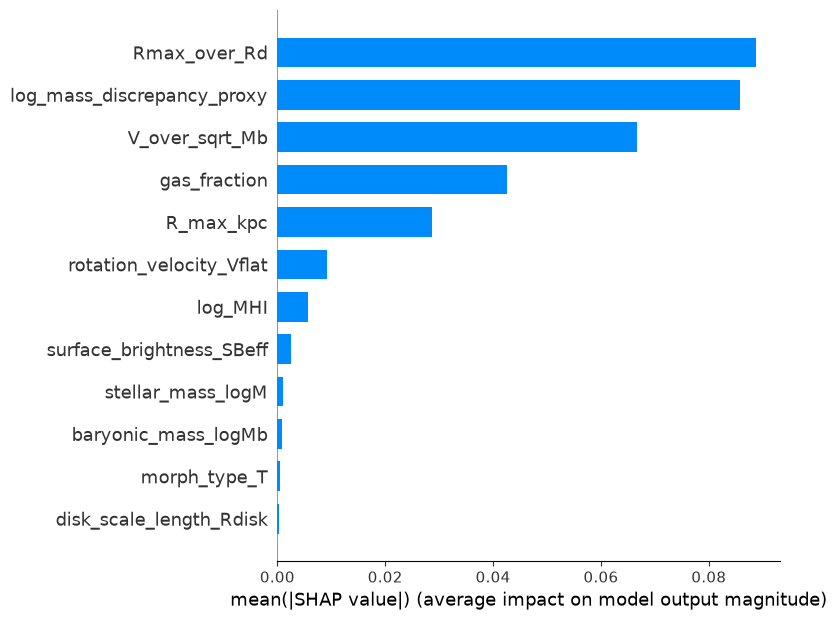

In [10]:
# ANSWERS RESEARCH QUESTION: Which observable properties are most determinative of dark matter fraction
shap.summary_plot(
    shap_values,
    X_arr,
    feature_names = feature_names,
    plot_type     = "bar",
    show          = True,
)